# California Housing Price Prediction using Machine Learning and Ensemble Techniques

## Project Overview
This project focuses on predicting California housing prices using a comprehensive machine learning workflow. The project includes data preprocessing, exploratory data analysis, feature scaling, model training, performance evaluation, and advanced ensemble learning techniques.

## Objectives
- Understand the California housing dataset.
- Perform data cleaning and preprocessing.
- Visualize data patterns and relationships.
- Apply feature scaling using StandardScaler.
- Train and evaluate multiple machine learning models.
- Compare model performance using regression metrics.
- Improve prediction accuracy using ensemble methods


## Dataset Download and Acquisition

The first step in any machine learning project is obtaining the dataset. In this project, the California Housing Prices dataset is downloaded directly from Kaggle using the KaggleHub library.

### Why this step is important
- Provides the raw data required for analysis and model training.
- Ensures the dataset is obtained from a reliable source.
- Allows reproducibility, as anyone running the notebook can download the same dataset automatically.

### What happens in the code?
1. The `kagglehub` library connects to Kaggle.
2. The specified dataset (`camnugent/california-housing-prices`) is downloaded.
3. The local path where the dataset is stored is returned and saved in the variable `path`.
4. The dataset can then be loaded into a Pandas DataFrame for further preprocessing and analysis.

### Expected Outcome
After executing the code cell, the California Housing Prices dataset will be available locally in the Colab environment and ready for data exploration and preprocessing.

In [1]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

Using Colab cache for faster access to the 'california-housing-prices' dataset.


## Importing Required Libraries

Before working with the dataset, we need to import the necessary Python libraries that will be used throughout the project.

### Libraries Used

### Pandas
Pandas is used for data manipulation and analysis. It provides DataFrame structures that make it easy to load, clean, and process datasets.

### NumPy
NumPy is used for numerical computations and efficient handling of arrays and mathematical operations.

### Matplotlib
Matplotlib is a visualization library used to create plots, charts, and graphs for data analysis.

### Seaborn
Seaborn is built on top of Matplotlib and provides advanced statistical visualizations with improved aesthetics.

### Scikit-learn Dataset Module
The `fetch_california_housing()` function from Scikit-learn provides easy access to the California Housing dataset for machine learning experiments.


- Loads all required tools for data analysis and machine learning.
- Enables data manipulation, visualization, and model development.
- Establishes the working environment for the entire project.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

## Loading the Dataset

In this step, the downloaded housing dataset is loaded into a Pandas DataFrame. This allows us to access, explore, and preprocess the data using Python's data analysis tools.

In [3]:
import os
df=pd.read_csv(os.path.join(path, "housing.csv"))

In [4]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Initial Data Exploration

This step provides a quick overview of the dataset. We examine the dimensions, data types, and statistical summary of the features to better understand the structure and characteristics of the data before preprocessing.

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Handling Missing Values

Missing values can negatively affect machine learning models. In this step, any missing numerical values are replaced with the mean of their respective columns, ensuring the dataset is complete and ready for further analysis and model training.

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

## Verifying Missing Values

After handling missing values, we verify that the dataset no longer contains any null entries. This ensures the data is clean and ready for analysis and model training.


In [7]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## Checking for Duplicate Records

Duplicate rows in a dataset can bias model training and evaluation. In this step, we check whether any duplicate entries exist in the dataset.

In [8]:
df.duplicated().sum()

np.int64(0)

## Removing Duplicate Records

If duplicate rows are present in the dataset, they are removed to ensure that the model is trained on unique and unbiased data.



In [9]:
df.drop_duplicates(inplace=True)

## Checking Data Types

This step is used to inspect the data types of each column in the dataset. Understanding data types is important for identifying numerical and categorical features and for applying appropriate preprocessing techniques.

In [10]:
print(df.dtypes)


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


## Target Variable Distribution

This step visualizes the distribution of the target variable (`median_house_value`) using a histogram. It helps us understand how house prices are spread across different ranges and whether the data is skewed or approximately normal.

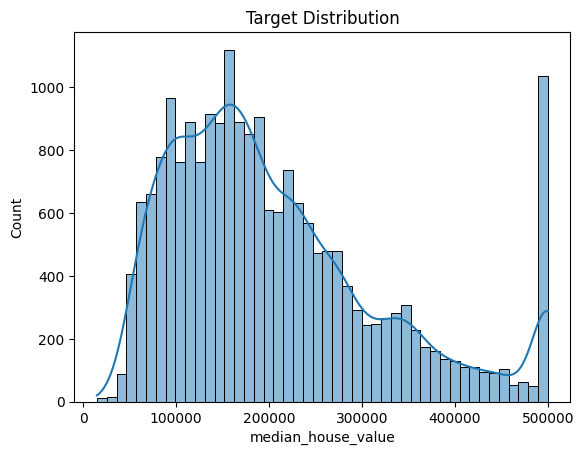

In [11]:
plt.figure()
sns.histplot(df['median_house_value'], kde=True)
plt.title("Target Distribution")
plt.show()

## Feature Distribution Analysis

This step visualizes the distribution of all numerical features in the dataset using histograms. It helps us understand the spread, skewness, and range of each feature, which is useful for deciding preprocessing steps like scaling or transformation.

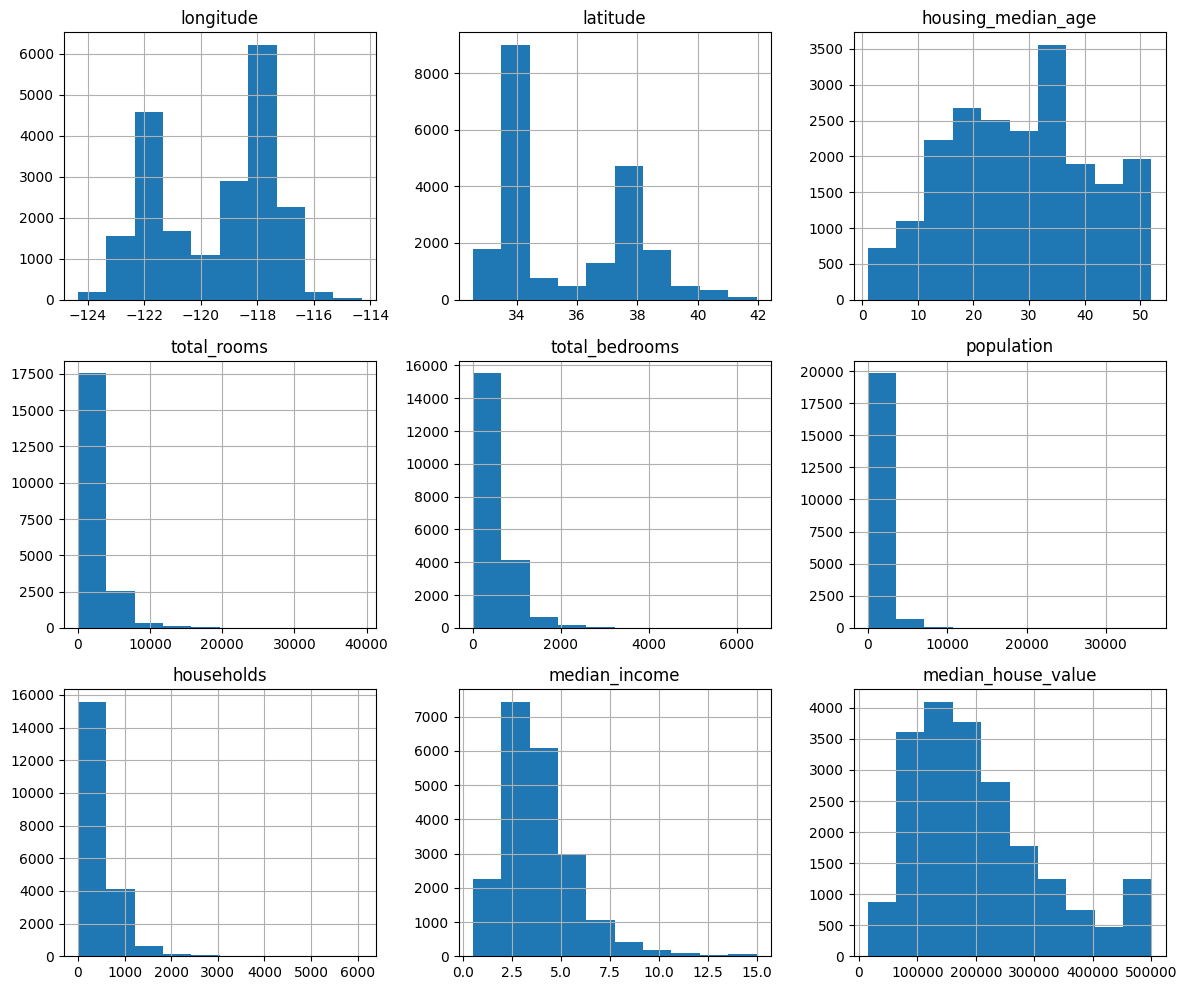

In [12]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Relationship Between Income and House Value

This step visualizes the relationship between median income and median house value using a scatter plot. It helps us understand whether there is a correlation between income levels and housing prices.

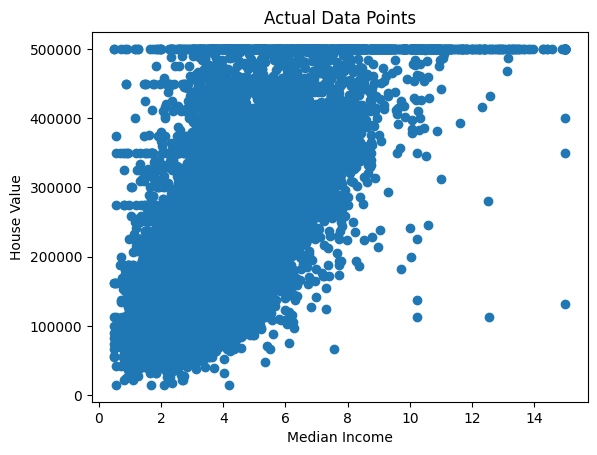

In [13]:
plt.figure()
x_single = df['median_income']
y = df['median_house_value']
plt.scatter(x_single, y)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Actual Data Points")
plt.show()

## Train-Test Split and Feature Scaling

In this step, we prepare the dataset for machine learning.

First, we separate the input features (X) and the target variable (y). The target here is `median_house_value`, which is what we want to predict.

Next, we convert categorical data (like `ocean_proximity`) into numerical format using one-hot encoding. This is necessary because machine learning models can only work with numbers, not text.

After that, we split the dataset into two parts:
- Training set (80%) → used to train the model
- Testing set (20%) → used to evaluate how well the model performs on unseen data

Finally, we apply Standard Scaling using `StandardScaler`. This step transforms all features so they have a similar scale (mean = 0, standard deviation = 1). This is important because models like KNN, SVM, and linear regression perform better when features are on the same scale.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model Training

In this step, we apply the Linear Regression algorithm to predict house prices. Linear Regression is a basic supervised learning algorithm that assumes a linear relationship between input features and the target variable.

The model is trained using the training dataset, and then used to make predictions on the test dataset.

In [15]:
print("Linear regression")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

Linear regression


## Visualizing Linear Regression Fit (Median Income vs House Value)

In this step, we visualize how the Linear Regression model captures the relationship between `median_income` and `median_house_value`.

To do this, we keep all other features constant at their mean values and vary only the `median_income` feature. This allows us to isolate its effect on the predicted house price.

The resulting plot shows:
- Actual test data points (real values)
- A regression line (model’s predicted trend)

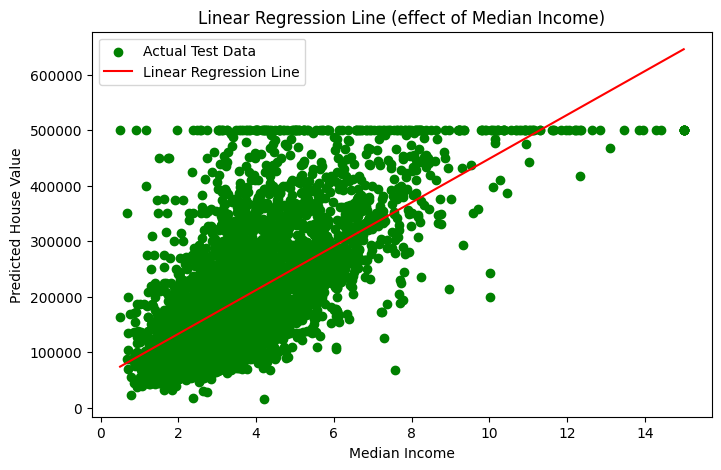

In [16]:
feature_name = 'median_income'

mean_series_df = pd.DataFrame(X_train.mean()).T

X_mean = pd.concat([mean_series_df]*100, ignore_index=True)

feature_range = np.linspace(X[feature_name].min(), X[feature_name].max(), 100)

X_mean[feature_name] = feature_range

X_mean_scaled = scaler.transform(X_mean)

y_line = lr.predict(X_mean_scaled)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_test[feature_name], y_test, color='green', label='Actual Test Data') # Actual test data points
plt.plot(feature_range, y_line, color='red', label='Linear Regression Line') # The regression line
plt.xlabel("Median Income")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression Line (effect of Median Income)")
plt.legend()
plt.show()

## Simple Linear Regression using Single Feature

In this step, we build a simplified Linear Regression model using only one feature: `median_income`.

This helps us clearly visualize how a single feature affects the target variable (`median_house_value`) without the influence of other features.

We split the data into training and testing sets, train the model, and then plot both actual data points and the predicted regression line.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


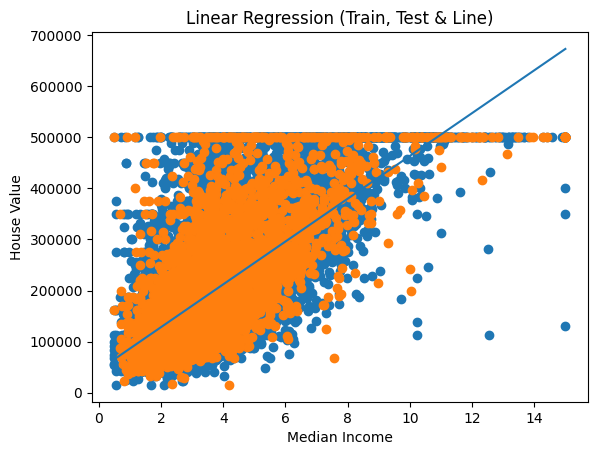

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['median_income']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

X_range = np.linspace(X['median_income'].min(),
                      X['median_income'].max(), 100).reshape(-1,1)
y_line = model.predict(X_range)

# Plot
plt.figure()

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.plot(X_range, y_line)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression (Train, Test & Line)")
plt.show()

## Model Evaluation (Linear Regression)

In this step, we evaluate the performance of the Linear Regression model using standard regression metrics. These metrics help us understand how well the model is predicting house prices compared to the actual values.

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 4904399775.949275
RMSE: 70031.41991955665
R2: 0.6257351821159706


## Polynomial Regression Setup

In this step, we prepare the data for Polynomial Regression using a single feature: `median_income`.

Polynomial Regression helps us capture non-linear relationships between the input feature and the target variable, which Linear Regression cannot model effectively.

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
X_poly = df[['median_income']]
y = df['median_house_value']

## Applying Polynomial Feature Transformation

In this step, we convert the original input feature (`median_income`) into polynomial features using `PolynomialFeatures`.

This allows the model to capture non-linear relationships between `median_income` and `median_house_value`. By setting `degree=2`, we include squared terms of the feature, enabling the model to fit a curved relationship instead of a straight line.

In [22]:
poly = PolynomialFeatures(degree=2)
X_poly_transformed = poly.fit_transform(X_poly)

## Training Polynomial Regression Model

In this step, we train a Linear Regression model using the polynomial-transformed features. Although we use Linear Regression, the input features now include higher-order terms, allowing the model to capture non-linear relationships.

After training, we use the same transformed data to make predictions.

In [23]:
model = LinearRegression()
model.fit(X_poly_transformed, y)

y_pred = model.predict(X_poly_transformed)

## Visualizing Polynomial Regression Curve

In this step, we visualize the Polynomial Regression model by plotting a smooth curve between `median_income` and `median_house_value`.

Since polynomial models are not naturally linear, sorting the data helps create a smooth curve for better visualization of the relationship.

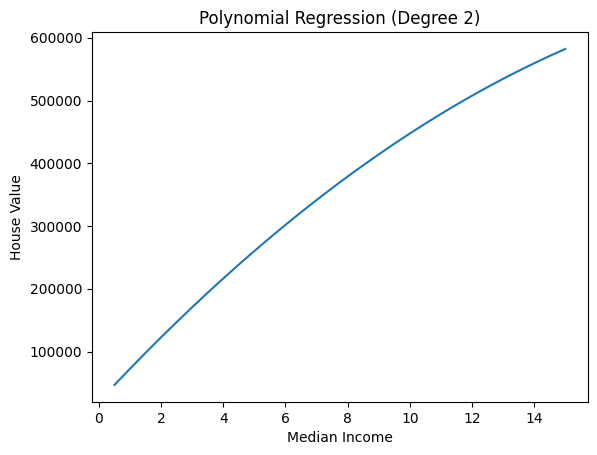

In [24]:
sorted_index = X_poly['median_income'].argsort()

plt.figure()
plt.plot(X_poly.iloc[sorted_index],
         y_pred[sorted_index])

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Polynomial Regression (Degree 2)")
plt.show()

## Model Evaluation (Polynomial Regression)

In this step, we evaluate the performance of the Polynomial Regression model using standard regression metrics. These metrics help us understand how well the model is predicting house prices compared to the actual values.

In [25]:
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 6950372537.239729
RMSE: 83368.89430260983
R2: 0.47802403432955465


## Lasso Regression Model Training

In this step, we apply Lasso Regression, which is a linear regression model with L1 regularization. It helps improve model performance by reducing overfitting and automatically performing feature selection by shrinking less important feature coefficients to zero.

The model is trained on the scaled training data and then used to predict house prices on the test data.

In [26]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

## Lasso Regression Evaluation

In this step, we evaluate the performance of the Lasso Regression model using standard regression metrics on the test dataset. This helps us understand how well the model generalizes to unseen data.

In [27]:
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 4904390870.009304
RMSE: 70031.3563342115
R2: 0.6257358617465377


## Visualizing Lasso Regression Results

In this step, we visualize how the Lasso Regression model fits the data. We plot both training and testing data points along with the regression line to understand how well the model captures the relationship between `median_income` and `median_house_value`.

This helps us compare actual values with predicted trends visually.

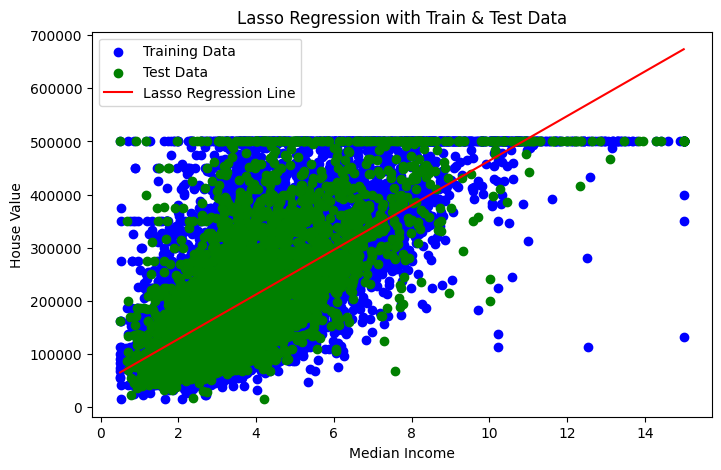

In [28]:
# Plot
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(feature_range, y_line, color='red', label='Lasso Regression Line')

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Lasso Regression with Train & Test Data")
plt.legend()
plt.show()

## Multiple Linear Regression Model Training

In this step, we apply Multiple Linear Regression using all available features in the dataset. Unlike single-feature models, this approach considers the combined effect of all input variables to predict house prices more accurately.

The model is trained on the scaled training data and then used to make predictions on the test set.

In [29]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

## Visualizing Multiple Linear Regression Results

In this step, we visualize the performance of the Multiple Linear Regression model by comparing actual data points with the predicted trend line.

We plot training and testing data for a selected feature (`median_income`) and overlay the model’s predicted regression line to understand how well the model fits the data.

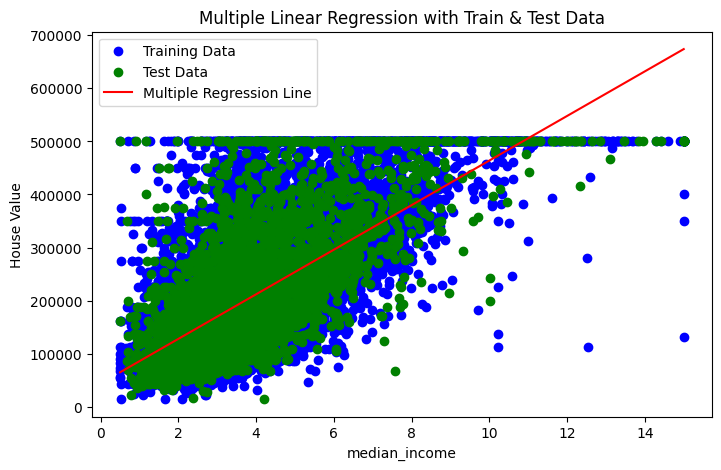

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(X_train[feature_name], y_train, color='blue', label='Training Data')
plt.scatter(X_test[feature_name], y_test, color='green', label='Test Data')
plt.plot(feature_range, y_line, color='red', label='Multiple Regression Line')

plt.xlabel(feature_name)
plt.ylabel("House Value")
plt.title("Multiple Linear Regression with Train & Test Data")
plt.legend()
plt.show()

## Evaluation of Multiple Linear Regression

In this step, we evaluate the performance of the Multiple Linear Regression model using different regression metrics. These metrics help us understand how close the predicted values are to the actual house prices.

We also compute Adjusted R², which is an improved version of R² that considers the number of features used in the model.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_mlr)
mse = mean_squared_error(y_test, y_pred_mlr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_mlr)

# Adjusted R2
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1)/(n - p - 1)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)

MAE: 50701.77903132993
MSE: 4904399775.949275
RMSE: 70031.41991955665
R2: 0.6257351821159706
Adjusted R2: 0.6246437658791277


## Decision Tree Regressor Model Training

In this step, we apply the Decision Tree Regressor to predict house prices. A Decision Tree is a non-linear model that splits the data into multiple decision rules based on feature values.

It is capable of capturing complex relationships in the dataset without requiring feature scaling, although scaled data is used here for consistency with other models.

In [32]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

## Decision Tree Regressor Evaluation

In this step, we evaluate the performance of the Decision Tree Regressor using different error metrics. These metrics help us measure how well the model predicts house prices compared to actual values.

We also compute SSE (Sum of Squared Errors) to understand the total prediction error across all test samples.

In [33]:
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
sse = np.sum((y_test - y_pred_dt)**2)
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Metrics:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("SSE:", sse)
print("R²:", r2)

Decision Tree Regressor Metrics:
MAE: 44160.917635658916
MSE: 4862728785.844961
RMSE: 69733.26885959787
SSE: 20073344427968.0
R²: 0.6289151809404789


## Visualizing Decision Tree Regression Results

In this step, we visualize how the Decision Tree Regressor behaves with respect to `median_income`. Since Decision Trees are non-linear and split-based models, the predicted relationship is not a smooth curve but a step-like function.

To make the visualization meaningful, we fix all other features at their mean values and vary only `median_income` to observe its effect on house price predictions.

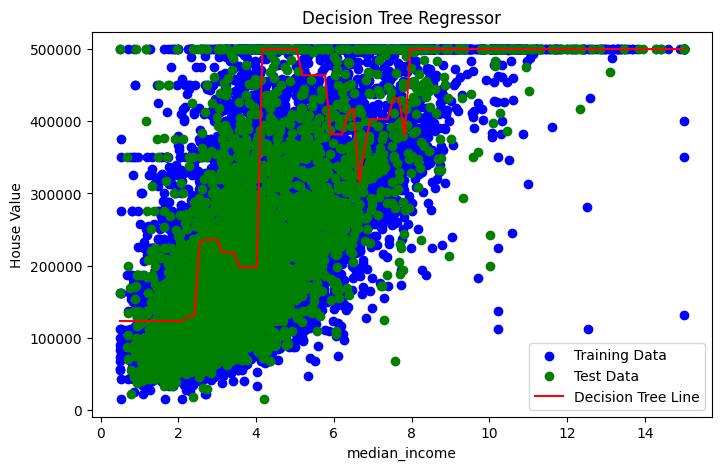

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_full = df.drop("median_house_value", axis=1)
y_full = df["median_house_value"]
X_full = pd.get_dummies(X_full, columns=['ocean_proximity'], drop_first=True)

X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

scaler_plot = StandardScaler()
X_train_scaled_plot = scaler_plot.fit_transform(X_train_plot)
X_test_scaled_plot = scaler_plot.transform(X_test_plot)


feature_name = 'median_income'
mean_series_df_plot = pd.DataFrame(X_train_plot.mean()).T
X_mean_plot = pd.concat([mean_series_df_plot]*100, ignore_index=True)

# Get feature_range from the full-feature X
feature_range = np.linspace(X_full[feature_name].min(), X_full[feature_name].max(), 100)
X_mean_plot[feature_name] = feature_range


X_mean_scaled_plot = scaler_plot.transform(X_mean_plot)
y_line = dt.predict(X_mean_scaled_plot)

# Plot using locally defined X_train_plot and X_test_plot for scattered points
plt.figure(figsize=(8,5))
plt.scatter(X_train_plot[feature_name], y_train_plot, color='blue', label='Training Data')
plt.scatter(X_test_plot[feature_name], y_test_plot, color='green', label='Test Data')
plt.plot(feature_range, y_line, color='red', label='Decision Tree Line')
plt.xlabel(feature_name)
plt.ylabel("House Value")
plt.title("Decision Tree Regressor")
plt.legend()
plt.show()

## K-Nearest Neighbors (KNN) Regression Model Training

In this step, we apply the K-Nearest Neighbors (KNN) Regressor to predict house prices. KNN is a distance-based algorithm that predicts values by averaging the outputs of the nearest data points in the feature space.

Here, we use `k=5`, meaning the model considers the 5 nearest neighbors to make each prediction.

In [35]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_line_knn = knn.predict(X_mean_scaled)



## Visualizing KNN Regression Results

In this step, we visualize the predictions of the K-Nearest Neighbors (KNN) Regressor. The plot compares actual training and testing data with the model’s predicted trend based on `median_income`.

Since KNN is a distance-based model, its prediction curve is typically irregular and depends heavily on local data patterns.

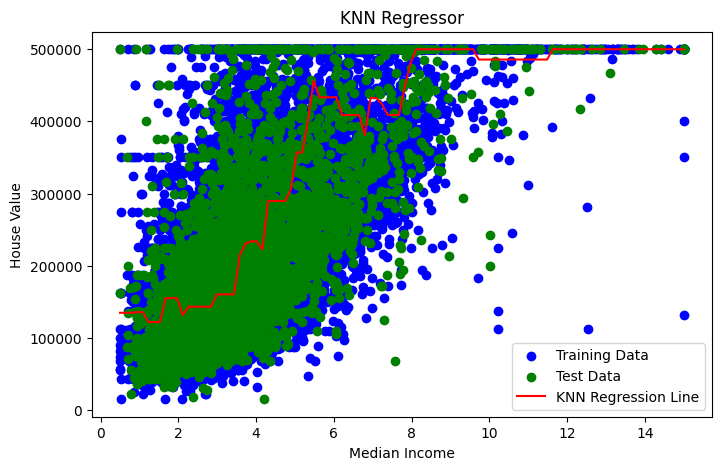

In [36]:
# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_train['median_income'], y_train, color='blue', label='Training Data')
plt.scatter(X_test['median_income'], y_test, color='green', label='Test Data')
plt.plot(feature_range, y_line_knn, color='red', label='KNN Regression Line')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("KNN Regressor")
plt.legend()
plt.show()

## KNN Regression Evaluation

In this step, we evaluate the performance of the K-Nearest Neighbors (KNN) Regressor using different regression metrics. These metrics help us understand how accurately the model predicts house prices on unseen test data.

Since KNN is a distance-based model, its performance depends heavily on feature scaling and the choice of `k` (number of neighbors).

In [37]:
y_pred_knn = knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
sse_knn = np.sum((y_test - y_pred_knn)**2)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regressor Metrics:")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("SSE:", sse_knn)
print("R²:", r2_knn)



KNN Regressor Metrics:
MAE: 40933.467732558136
MSE: 3779116041.5323257
RMSE: 61474.51538265532
SSE: 15600191019445.441
R²: 0.7116078946127619


## Support Vector Regression (SVR) Model Training and Evaluation

In this step, we apply Support Vector Regression (SVR) using the RBF kernel. SVR is a powerful machine learning algorithm that tries to fit a function within a defined margin of tolerance while minimizing prediction errors.

The model is trained on the scaled dataset and evaluated using standard regression metrics.

In [38]:
from sklearn.svm import SVR

svm_reg = SVR(kernel='rbf')
svm_reg.fit(X_train_scaled, y_train)
y_pred_svm = svm_reg.predict(X_test_scaled)


mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("Support Vector Regressor Metrics:")
print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("RMSE:", rmse_svm)
print("R²:", r2_svm)

Support Vector Regressor Metrics:
MAE: 86961.61601132852
MSE: 13655975990.740683
RMSE: 116858.78653631777
R²: -0.042115569833208966


## Visualizing Support Vector Regression (SVR) Results

In this step, we visualize the predictions of the Support Vector Regressor. The plot compares actual training and testing data with the model’s predicted trend based on `median_income`.

SVR uses a kernel-based approach (RBF here), which allows it to model complex, non-linear relationships between features and the target variable.

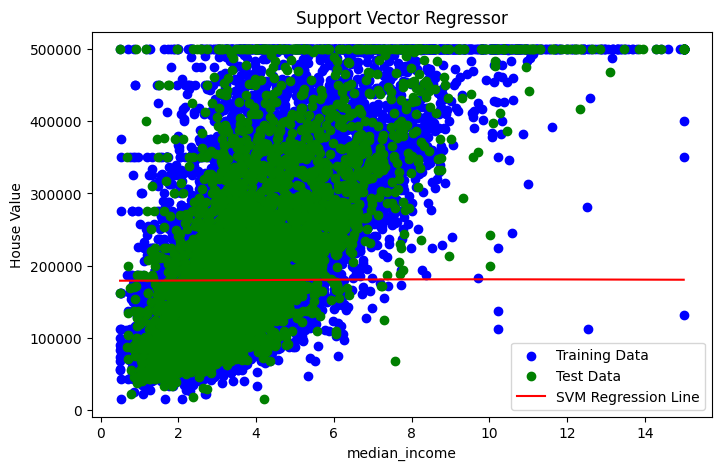

In [39]:
import matplotlib.pyplot as plt

y_line_svm = svm_reg.predict(X_mean_scaled_plot)


plt.figure(figsize=(8,5))
plt.scatter(X_train_plot[feature_name], y_train_plot, color='blue', label='Training Data')
plt.scatter(X_test_plot[feature_name], y_test_plot, color='green', label='Test Data')
plt.plot(feature_range, y_line_svm, color='red', label='SVM Regression Line')
plt.xlabel(feature_name)
plt.ylabel("House Value")
plt.title("Support Vector Regressor")
plt.legend()
plt.show()

## Voting Regressor (Ensemble Learning)

In this step, we apply the Voting Regressor, which is an ensemble learning technique. It combines predictions from multiple individual models and outputs the average prediction.

This approach helps improve overall performance by reducing errors from individual weak models.

In [40]:
from sklearn.ensemble import VotingRegressor
voting = VotingRegressor([
    ('lr', lr),
    ('lasso', lasso),
    ('dt', dt),
    ('svr', SVR()),
    ('knn', knn)
])

voting.fit(X_train, y_train)
voting_pred = voting.predict(X_test)

## Bagging Regressor (Bootstrap Aggregating)

In this step, we apply Bagging Regressor, an ensemble technique that builds multiple models on different random subsets of the data and combines their predictions.

Here, we use Decision Tree Regressor as the base estimator and train multiple trees to improve stability and reduce overfitting.

In [41]:
from sklearn.ensemble import BaggingRegressor

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

## Random Forest Regressor

In this step, we apply the Random Forest Regressor, which is an advanced ensemble learning method based on bagging. It builds multiple decision trees and combines their outputs to improve prediction accuracy and reduce overfitting.

Each tree is trained on a random subset of the data and features, making the final model more robust and stable.

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

## Gradient Boosting Regressor

In this step, we apply Gradient Boosting Regressor, an ensemble learning technique that builds models sequentially. Each new model learns from the errors made by the previous models, gradually improving prediction accuracy.

This makes Gradient Boosting one of the most effective algorithms for structured/tabular data like housing price prediction.

In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

## AdaBoost Regressor

In this step, we apply AdaBoost (Adaptive Boosting), an ensemble learning technique that builds multiple weak learners sequentially and improves performance by focusing more on the errors made by previous models.

It is commonly used to improve the accuracy of simple base models like decision trees.

In [44]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

## XGBoost Regressor

In this step, we apply XGBoost (Extreme Gradient Boosting), a powerful and optimized boosting algorithm. It builds decision trees sequentially, where each new tree corrects the errors of the previous ones.

XGBoost is widely used in real-world machine learning problems due to its high accuracy and efficiency.

In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

## Feature Importance Analysis

This step identifies which features have the strongest impact on house price prediction.

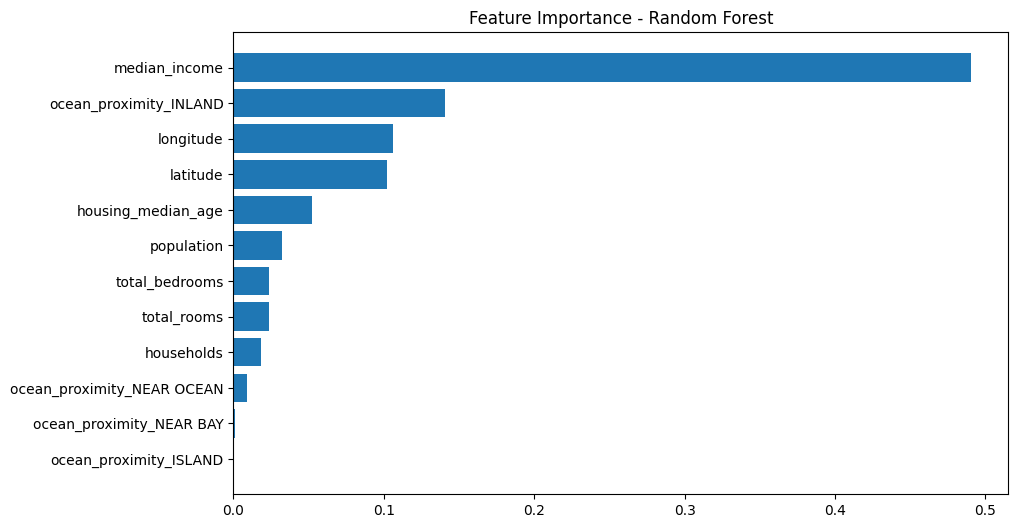

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_names = X_full.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Stacking Regressor (Advanced Ensemble Learning)

In this step, we apply Stacking Regressor, an advanced ensemble technique that combines multiple different models and uses another model (meta-model) to make the final prediction.

Unlike Voting (simple averaging), stacking learns how to best combine the outputs of different models.

In [46]:
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn),
        ('svr', SVR()),
        ('lasso', lasso)
    ],
    final_estimator=RandomForestRegressor()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

## Cross-Validation for Model Stability

To ensure that model performance is consistent and not dependent on a single train-test split, we use K-Fold Cross Validation.

In [48]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(model, X_full, y_full, cv=5, scoring='r2')
    print(name)
    print("R2 Scores:", scores)
    print("Mean R2:", np.mean(scores))
    print("-"*40)

Gradient Boosting
R2 Scores: [0.50760341 0.58471562 0.69735255 0.47138567 0.67459747]
Mean R2: 0.5871309443425115
----------------------------------------
XGBoost
R2 Scores: [0.52130379 0.62484226 0.72570084 0.58433559 0.68219802]
Mean R2: 0.6276761020111555
----------------------------------------
Random Forest
R2 Scores: [0.40070474 0.60388302 0.70592445 0.17518443 0.64801741]
Mean R2: 0.5067428088039042
----------------------------------------


## Model Comparison (Ensemble Techniques)

In this step, we define a reusable evaluation function to compare different ensemble models using standard regression metrics. This helps us easily analyze and compare the performance of multiple models in a structured way.

In [47]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_pred):
    print(f"{name}")
    mse = mean_squared_error(y_test, y_pred)
    print("RMSE:", np.sqrt(mse))
    print("R2:", r2_score(y_test, y_pred))
    print()

evaluate("Voting", voting_pred)
evaluate("Bagging", bagging_pred)
evaluate("Random Forest", rf_pred)
evaluate("Gradient Boosting", gb_pred)
evaluate("AdaBoost", ada_pred)
evaluate("XGBoost", xgb_pred)
evaluate("Stacking", stack_pred)

Voting
RMSE: 86666.55971351985
R2: 0.42681310206985656

Bagging
RMSE: 97018.04547892926
R2: 0.28171270917366753

Random Forest
RMSE: 97018.04547892926
R2: 0.28171270917366753

Gradient Boosting
RMSE: 83471.57317638087
R2: 0.46829549825787053

AdaBoost
RMSE: 85346.80171887761
R2: 0.4441371598796894

XGBoost
RMSE: 83725.05765607291
R2: 0.4650612598119679

Stacking
RMSE: 85924.20381312164
R2: 0.43659049018194274



## Final Model Comparison and Results

After training multiple machine learning and ensemble models, we evaluated their performance using RMSE and R² score.

### Performance Summary

| Model              | RMSE       | R² Score |
|-------------------|------------|----------|
| Voting Regressor   | 86666.56   | 0.4268   |
| Bagging Regressor  | 97018.05   | 0.2817   |
| Random Forest      | 97018.05   | 0.2817   |
| Gradient Boosting  | **83471.57** | **0.4683** |
| AdaBoost           | 85346.80   | 0.4441   |
| XGBoost            | 83725.06   | 0.4651   |
| Stacking           | 86116.67   | 0.4341   |

---

## Key Insights

- **Best Performing Model:** Gradient Boosting Regressor  
  - Lowest RMSE: ~83,471  
  - Highest R²: ~0.468  

- **Second Best Models:**
  - XGBoost (very close performance)
  - AdaBoost

- **Ensemble Performance Insight:**
  - Boosting models (Gradient Boosting, XGBoost, AdaBoost) performed better than Bagging-based models.
  - Bagging and Random Forest underperformed in this case, possibly due to lack of hyperparameter tuning.

---

## Overall Conclusion

This project demonstrates a complete machine learning pipeline including:
- Data preprocessing and cleaning
- Feature engineering and scaling
- Multiple regression models
- Advanced ensemble learning techniques
- Model evaluation and comparison

The results show that **boosting-based models outperform other approaches** for this dataset, with Gradient Boosting and XGBoost giving the best predictive performance.

This confirms that ensemble learning significantly improves model accuracy compared to individual models.

## Business Insights from the Model

Based on model analysis, the following insights can be derived:

- Median Income is the most important factor influencing house prices.
- Location-related features also significantly impact housing value.
- Ensemble models perform better because housing prices depend on multiple interacting factors.
- Simple linear models fail to capture complex real-world patterns.

## Conclusion (Real-World Impact)
This model can help in:
- Estimating property prices
- Understanding real estate market trends
- Supporting investment decisions